# NLP Project 13: Fake News Detection

**Alternative Kaggle Dataset:** Fake and Real News Dataset

This project analyzes news articles labeled as **Fake** or **Real** using NLP and machine learning.

### Tasks
1. Collect news article dataset
2. Preprocess article content
3. Build fake news detection model
4. Classify news articles
5. Evaluate detection accuracy

### Workflow
Dataset → Cleaning → Text Preprocessing → TF-IDF → Naive Bayes → Logistic Regression → GridSearchCV → Evaluation → Prediction

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from collections import Counter
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

STOP_WORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    return " ".join(
        LEMMATIZER.lemmatize(w)
        for w in text.split()
        if w not in STOP_WORDS and len(w) > 2
    )

def evaluate_model(name, model, X_test, y_test):
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, pred, average="weighted", zero_division=0)
    print(f"{name} Accuracy: {acc*100:.2f}%")
    print(f"Weighted Precision: {precision*100:.2f}%")
    print(f"Weighted Recall: {recall*100:.2f}%")
    print(f"Weighted F1-score: {f1*100:.2f}%")
    print(classification_report(y_test, pred, zero_division=0))
    return pred, acc, precision, recall, f1


## 1. Download Kaggle Dataset

In [2]:
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")
print("Dataset path:", path)

for root, dirs, files in os.walk(path):
    if files:
        print(root, files[:10])

100%|██████████| 41.0M/41.0M [00:00<00:00, 111MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/clmentbisaillon/fake-and-real-news-dataset/versions/1
/root/.cache/kagglehub/datasets/clmentbisaillon/fake-and-real-news-dataset/versions/1 ['True.csv', 'Fake.csv']


## 2. Locate and Load Fake/Real News

In [3]:
fake_path = None
true_path = None

for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower() == "fake.csv":
            fake_path = os.path.join(root, file)
        elif file.lower() == "true.csv":
            true_path = os.path.join(root, file)

print("Fake file:", fake_path)
print("Real file:", true_path)

if fake_path is None or true_path is None:
    raise FileNotFoundError("Fake.csv and/or True.csv was not found.")

fake_df = pd.read_csv(fake_path)
true_df = pd.read_csv(true_path)

print("Fake news:", fake_df.shape)
print("Real news:", true_df.shape)

Fake file: /root/.cache/kagglehub/datasets/clmentbisaillon/fake-and-real-news-dataset/versions/1/Fake.csv
Real file: /root/.cache/kagglehub/datasets/clmentbisaillon/fake-and-real-news-dataset/versions/1/True.csv
Fake news: (23481, 4)
Real news: (21417, 4)


## 3. Add Labels and Combine

In [4]:
fake_df["label"] = 0
true_df["label"] = 1

df = pd.concat([fake_df, true_df], ignore_index=True)

df["label_name"] = df["label"].map({0: "Fake", 1: "Real"})

print("Combined shape:", df.shape)
print(df["label_name"].value_counts())
display(df.head())

Combined shape: (44898, 6)
label_name
Fake    23481
Real    21417
Name: count, dtype: int64


,title,text,subject,date,label,label_name
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0,Fake
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0,Fake
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0,Fake
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0,Fake
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0,Fake


## 4. Inspect the Dataset

In [5]:
print("Columns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Columns: ['title', 'text', 'subject', 'date', 'label', 'label_name']

Missing values:
title         0
text          0
subject       0
date          0
label         0
label_name    0
dtype: int64

Duplicates: 209


## 5. Clean Article Content

In [6]:
df = df.drop_duplicates().copy()

df["title"] = df["title"].fillna("").astype(str)
df["text"] = df["text"].fillna("").astype(str)

df["article"] = df["title"] + " " + df["text"]

df = df[df["article"].str.strip().str.len() > 20].copy()

print("Shape after cleaning:", df.shape)
display(df[["title", "article", "label_name"]].head())

Shape after cleaning: (44689, 7)


,title,article,label_name
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump Sends Out Embarrassing New Year’...,Fake
1,Drunk Bragging Trump Staffer Started Russian ...,Drunk Bragging Trump Staffer Started Russian ...,Fake
2,Sheriff David Clarke Becomes An Internet Joke...,Sheriff David Clarke Becomes An Internet Joke...,Fake
3,Trump Is So Obsessed He Even Has Obama’s Name...,Trump Is So Obsessed He Even Has Obama’s Name...,Fake
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis Just Called Out Donald Trump Dur...,Fake


## 6. Fake vs Real Distribution

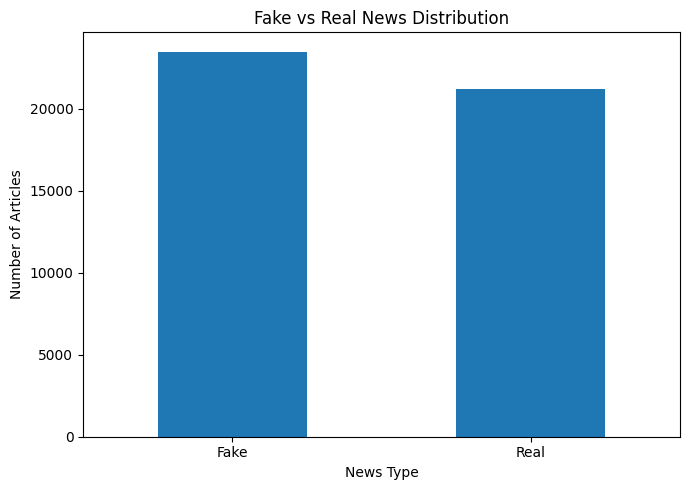

In [7]:
counts = df["label_name"].value_counts()

plt.figure(figsize=(7,5))
counts.plot(kind="bar")
plt.title("Fake vs Real News Distribution")
plt.xlabel("News Type")
plt.ylabel("Number of Articles")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Text Preprocessing

In [8]:
df["clean_article"] = df["article"].apply(preprocess_text)

display(
    df[["article", "clean_article", "label_name"]].head()
)

,article,clean_article,label_name
0,Donald Trump Sends Out Embarrassing New Year’...,donald trump sends embarrassing new year eve m...,Fake
1,Drunk Bragging Trump Staffer Started Russian ...,drunk bragging trump staffer started russian c...,Fake
2,Sheriff David Clarke Becomes An Internet Joke...,sheriff david clarke becomes internet joke thr...,Fake
3,Trump Is So Obsessed He Even Has Obama’s Name...,trump obsessed even obama name coded website i...,Fake
4,Pope Francis Just Called Out Donald Trump Dur...,pope francis called donald trump christmas spe...,Fake


## 8. Frequent Words

,Term,Frequency
0,trump,149085
1,said,131837
2,state,62308
3,president,58502
4,would,55306
5,people,42458
6,year,42146
7,republican,41461
8,one,39804
9,new,32948


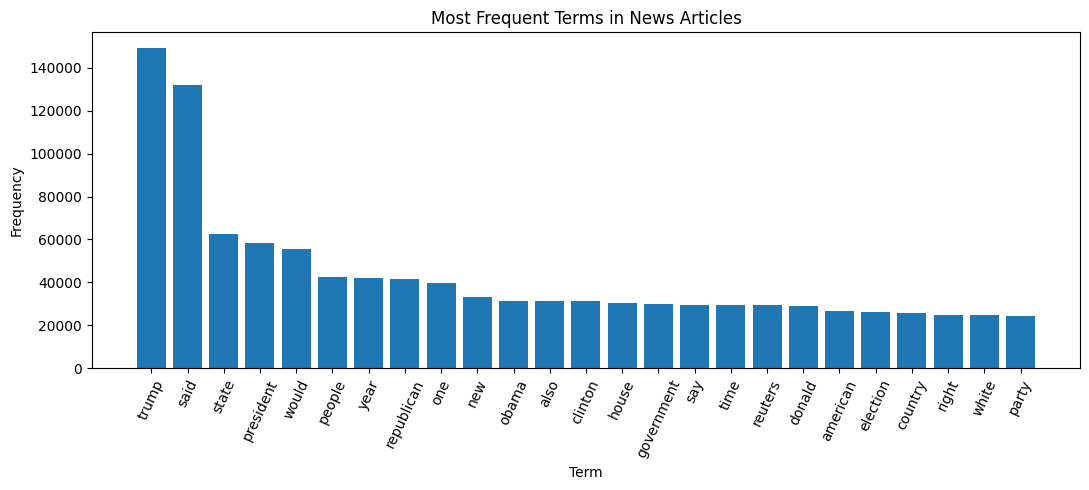

In [9]:
words = " ".join(df["clean_article"]).split()
top_words = pd.DataFrame(
    Counter(words).most_common(25),
    columns=["Term", "Frequency"]
)

display(top_words)

plt.figure(figsize=(11,5))
plt.bar(top_words["Term"], top_words["Frequency"])
plt.title("Most Frequent Terms in News Articles")
plt.xlabel("Term")
plt.ylabel("Frequency")
plt.xticks(rotation=65)
plt.tight_layout()
plt.show()

## 9. Compare Fake and Real News Terms

In [10]:
for label in ["Fake", "Real"]:
    words = " ".join(
        df.loc[df["label_name"] == label, "clean_article"]
    ).split()

    temp = pd.DataFrame(
        Counter(words).most_common(15),
        columns=["Term", "Frequency"]
    )

    print("\nTop terms in", label, "news:")
    display(temp)


Top terms in Fake news:


,Term,Frequency
0,trump,89438
1,said,33956
2,president,29560
3,people,27195
4,one,26083
5,state,24258
6,would,23826
7,obama,21414
8,clinton,21032
9,time,19640



Top terms in Real news:


,Term,Frequency
0,said,97881
1,trump,59647
2,state,38050
3,would,31480
4,president,28942
5,reuters,28807
6,republican,23838
7,year,22607
8,government,20098
9,house,18328


## 10. Train-Test Split

In [11]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean_article"],
    df["label"],
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))

Training samples: 35751
Testing samples: 8938


## 11. TF-IDF Feature Extraction

In [12]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=15000,
    ngram_range=(1,2),
    min_df=2
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print("Training matrix:", X_train.shape)
print("Testing matrix:", X_test.shape)

Training matrix: (35751, 15000)
Testing matrix: (8938, 15000)


## 12. Multinomial Naive Bayes

In [13]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred, nb_acc, nb_precision, nb_recall, nb_f1 = evaluate_model(
    "Multinomial Naive Bayes",
    nb_model,
    X_test,
    y_test
)

Multinomial Naive Bayes Accuracy: 94.62%
Weighted Precision: 94.62%
Weighted Recall: 94.62%
Weighted F1-score: 94.62%
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      4696
           1       0.94      0.95      0.94      4242

    accuracy                           0.95      8938
   macro avg       0.95      0.95      0.95      8938
weighted avg       0.95      0.95      0.95      8938



## 13. Logistic Regression

In [14]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred, lr_acc, lr_precision, lr_recall, lr_f1 = evaluate_model(
    "Logistic Regression",
    lr_model,
    X_test,
    y_test
)

Logistic Regression Accuracy: 98.79%
Weighted Precision: 98.79%
Weighted Recall: 98.79%
Weighted F1-score: 98.79%
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4696
           1       0.98      0.99      0.99      4242

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



## 14. GridSearchCV

In [15]:
param_grid = {
    "C": [0.5, 1.0, 2.0],
    "solver": ["liblinear"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV weighted F1:", round(grid.best_score_, 4))

best_model = grid.best_estimator_

grid_pred, grid_acc, grid_precision, grid_recall, grid_f1 = evaluate_model(
    "Tuned Logistic Regression",
    best_model,
    X_test,
    y_test
)

Best parameters: {'C': 2.0, 'solver': 'liblinear'}
Best CV weighted F1: 0.9882
Tuned Logistic Regression Accuracy: 99.03%
Weighted Precision: 99.03%
Weighted Recall: 99.03%
Weighted F1-score: 99.03%
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4696
           1       0.99      0.99      0.99      4242

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



## 15. Model Comparison

In [16]:
comparison = pd.DataFrame({
    "Model": [
        "Multinomial NB",
        "Logistic Regression",
        "Tuned Logistic Regression"
    ],
    "Accuracy (%)": [
        nb_acc*100,
        lr_acc*100,
        grid_acc*100
    ],
    "Weighted Precision (%)": [
        nb_precision*100,
        lr_precision*100,
        grid_precision*100
    ],
    "Weighted Recall (%)": [
        nb_recall*100,
        lr_recall*100,
        grid_recall*100
    ],
    "Weighted F1 (%)": [
        nb_f1*100,
        lr_f1*100,
        grid_f1*100
    ]
})

display(comparison.round(2))

,Model,Accuracy (%),Weighted Precision (%),Weighted Recall (%),Weighted F1 (%)
0,Multinomial NB,94.62,94.62,94.62,94.62
1,Logistic Regression,98.79,98.79,98.79,98.79
2,Tuned Logistic Regression,99.03,99.03,99.03,99.03


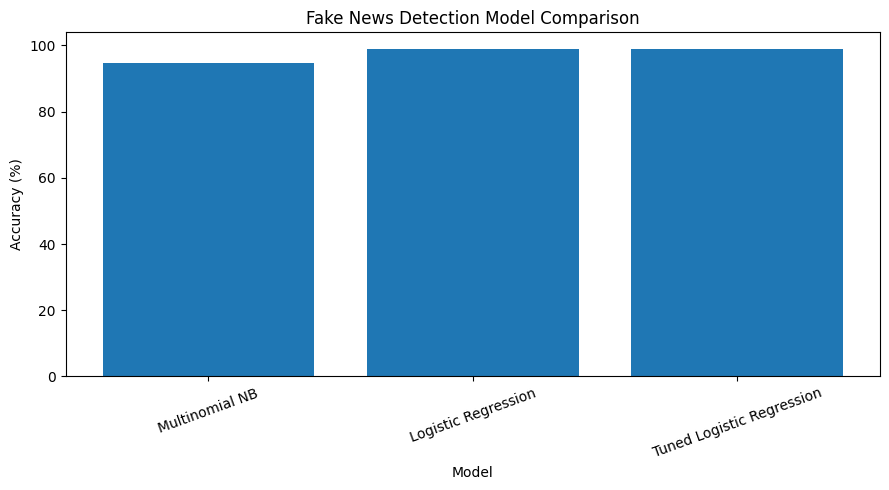

In [17]:
plt.figure(figsize=(9,5))
plt.bar(comparison["Model"], comparison["Accuracy (%)"])
plt.title("Fake News Detection Model Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 16. Confusion Matrix

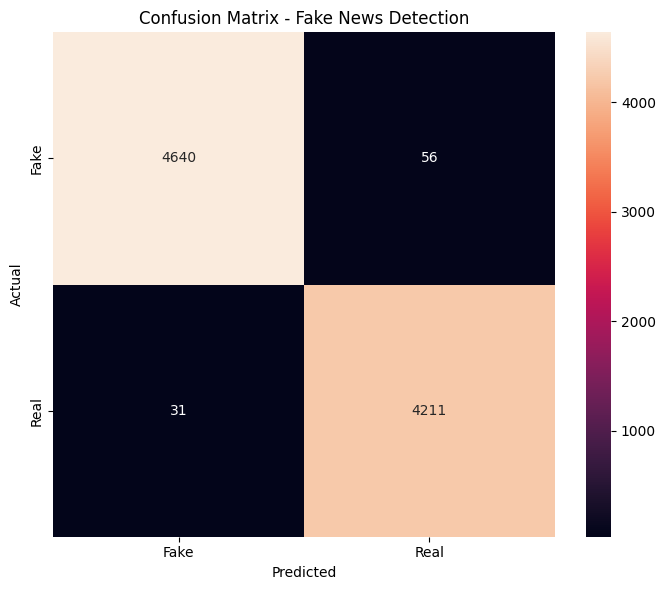

In [18]:
cm = confusion_matrix(
    y_test,
    grid_pred,
    labels=best_model.classes_
)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Fake News Detection")
plt.tight_layout()
plt.show()

## 17. Important TF-IDF Features

In [19]:
feature_names = np.array(vectorizer.get_feature_names_out())
coefficients = best_model.coef_[0]

top_real = feature_names[np.argsort(coefficients)[-20:]][::-1]
top_fake = feature_names[np.argsort(coefficients)[:20]]

print("Terms associated with REAL news:")
print(", ".join(top_real))

print("\nTerms associated with FAKE news:")
print(", ".join(top_fake))

Terms associated with REAL news:
reuters, said, washington reuters, president donald, reuters president, wednesday, washington, tuesday, thursday, nov, friday, presidential, president barack, monday, minister, said statement, democratic, york reuters, london, spokesman

Terms associated with FAKE news:
video, image, read, president trump, gop, hillary, featured image, featured, wire, obama, watch, america, breaking, american, getty, com, sen, getty image, president obama, rep


## 18. Classify a New News Article

In [20]:
def classify_news(article):
    cleaned = preprocess_text(article)
    vector = vectorizer.transform([cleaned])

    prediction = best_model.predict(vector)[0]
    probability = best_model.predict_proba(vector)[0].max()

    label = "Real" if prediction == 1 else "Fake"

    return {
        "Prediction": label,
        "Confidence": round(float(probability) * 100, 2)
    }

sample_news = (
    "Government officials announced a new economic policy after reviewing "
    "recent economic data and said that the policy will be implemented soon."
)

classify_news(sample_news)

{'Prediction': 'Real', 'Confidence': 62.53}

## 19. Final Detection Report

In [21]:
best_row = comparison.loc[
    comparison["Weighted F1 (%)"].idxmax()
]

print("FAKE NEWS DETECTION REPORT")
print("--------------------------")
print("Total articles analyzed:", len(df))
print("Fake articles:", int((df["label"] == 0).sum()))
print("Real articles:", int((df["label"] == 1).sum()))
print("Best model:", best_row["Model"])
print("Best accuracy:", round(best_row["Accuracy (%)"], 2), "%")
print("Best weighted F1:", round(best_row["Weighted F1 (%)"], 2), "%")

FAKE NEWS DETECTION REPORT
--------------------------
Total articles analyzed: 44689
Fake articles: 23478
Real articles: 21211
Best model: Tuned Logistic Regression
Best accuracy: 99.03 %
Best weighted F1: 99.03 %


## 20. Conclusion

The project uses NLP preprocessing and TF-IDF feature extraction to classify news articles as Fake or Real. Multinomial Naive Bayes, Logistic Regression and tuned Logistic Regression are compared using accuracy, precision, recall and F1-score.

The final model can also classify new news article text.

**Note:** All evaluation metrics are calculated from the actual dataset when the notebook is executed; no accuracy values are manually fabricated.